<a href="https://colab.research.google.com/github/Ewanjohndennis/ML_LAB/blob/main/assignment9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 9 - Week 3 September

## Learning Objective
Learn Support Vector Machines (SVM).

# 1. Implementation of Linear SVM from Scratch

## Problem Statement

A college wants to classify students into two categories—**Pass** and **Fail**—based on their performance in two internal assessment tests.

Each student is represented using two features:

- Internal Test 1 Score
- Internal Test 2 Score

The target class is:

- **−1 → Fail**
- **+1 → Pass**

The following training dataset is provided:

| Student | Test 1 | Test 2 | Class |
|---|---:|---:|---:|
| S1 | 2 | 3 | −1 |
| S2 | 3 | 2 | −1 |
| S3 | 3 | 4 | −1 |
| S4 | 4 | 3 | −1 |
| S5 | 6 | 7 | +1 |
| S6 | 7 | 6 | +1 |
| S7 | 7 | 8 | +1 |
| S8 | 8 | 7 | +1 |

## Task

Implement a **Linear Support Vector Machine (SVM) classifier from scratch** using Python and NumPy, without using Scikit-learn's `SVC` or any other built-in SVM implementation.

Your program should:

1. Represent the input data using NumPy arrays.
2. Visualize the two classes using a scatter plot.
3. Initialize the weight vector `w` and bias `b`.
4. Implement the linear decision function:

   \[
   f(x) = w^T x + b
   \]

5. Classify samples using the sign of the decision function.
6. Implement the SVM training process using an appropriate optimization approach such as gradient descent/sub-gradient descent.
7. Train the model to find the optimal values of `w` and `b` that maximize the margin between the two classes.
8. Identify the support vectors.
9. Plot:
   - The two classes
   - The separating hyperplane
   - The margin boundaries
   - The support vectors
10. Use the trained SVM model to predict the classes of the following new students:

| Student | Test 1 | Test 2 |
|---|---:|---:|
| A | 4 | 5 |
| B | 7 | 7 |
| C | 5 | 5 |
| D | 2 | 4 |

11. Display the predicted class for each student.

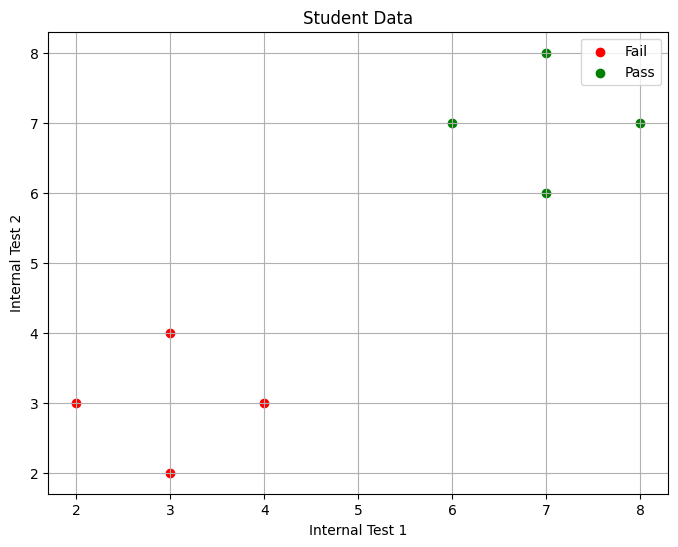

Weight vector: [0.34070754 0.33592635]
Bias: -3.350999999999742

Training Predictions
Student 1 | Actual: Fail | Predicted: Fail
Student 2 | Actual: Fail | Predicted: Fail
Student 3 | Actual: Fail | Predicted: Fail
Student 4 | Actual: Fail | Predicted: Fail
Student 5 | Actual: Pass | Predicted: Pass
Student 6 | Actual: Pass | Predicted: Pass
Student 7 | Actual: Pass | Predicted: Pass
Student 8 | Actual: Pass | Predicted: Pass

Support Vectors
Student 3 : [3 4]
Student 4 : [4 3]
Student 5 : [6 7]
Student 6 : [7 6]


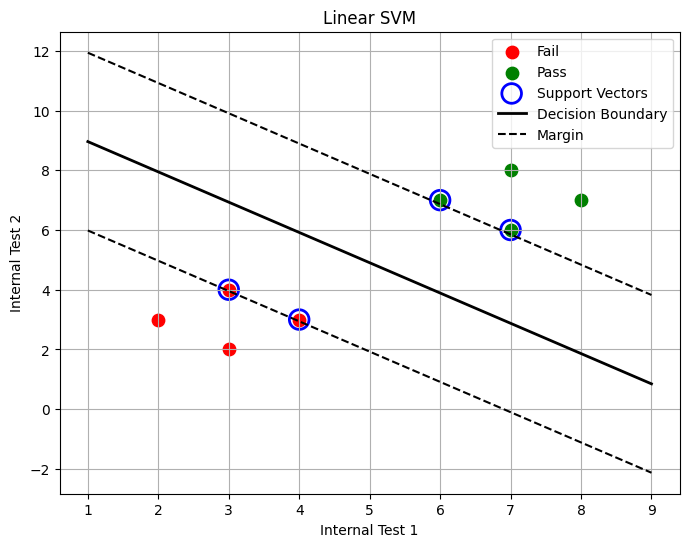


New Student Predictions
Student A | Test 1: 4 | Test 2: 5 | Prediction: Fail
Student B | Test 1: 7 | Test 2: 7 | Prediction: Pass
Student C | Test 1: 5 | Test 2: 5 | Prediction: Pass
Student D | Test 1: 2 | Test 2: 4 | Prediction: Fail


In [1]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [2, 3],
    [3, 2],
    [3, 4],
    [4, 3],
    [6, 7],
    [7, 6],
    [7, 8],
    [8, 7]
])

y = np.array([-1, -1, -1, -1, 1, 1, 1, 1])

plt.figure(figsize=(8, 6))
plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', label='Fail')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='green', label='Pass')
plt.xlabel("Internal Test 1")
plt.ylabel("Internal Test 2")
plt.title("Student Data")
plt.legend()
plt.grid()
plt.show()

w = np.zeros(2)
b = 0
learning_rate = 0.001
C = 1
epochs = 10000

for epoch in range(epochs):
    for i in range(len(X)):
        decision = np.dot(w, X[i]) + b

        if y[i] * decision >= 1:
            w = w - learning_rate * w
        else:
            w = w - learning_rate * (w - C * y[i] * X[i])
            b = b + learning_rate * C * y[i]

print("Weight vector:", w)
print("Bias:", b)

def decision_function(x):
    return np.dot(x, w) + b

def predict(x):
    if decision_function(x) >= 0:
        return 1
    return -1

predictions = np.array([predict(x) for x in X])

print("\nTraining Predictions")
for i in range(len(X)):
    actual = "Pass" if y[i] == 1 else "Fail"
    predicted = "Pass" if predictions[i] == 1 else "Fail"
    print("Student", i + 1, "| Actual:", actual, "| Predicted:", predicted)

decision_values = np.array([decision_function(x) for x in X])

support_vector_indices = np.where(np.abs(decision_values) <= 1.1)[0]
support_vectors = X[support_vector_indices]

print("\nSupport Vectors")
for i in support_vector_indices:
    print("Student", i + 1, ":", X[i])

plt.figure(figsize=(8, 6))

plt.scatter(X[y == -1, 0], X[y == -1, 1],
            color='red', s=80, label='Fail')

plt.scatter(X[y == 1, 0], X[y == 1, 1],
            color='green', s=80, label='Pass')

plt.scatter(support_vectors[:, 0],
            support_vectors[:, 1],
            s=200,
            facecolors='none',
            edgecolors='blue',
            linewidths=2,
            label='Support Vectors')

x_values = np.linspace(1, 9, 100)

y_boundary = -(w[0] * x_values + b) / w[1]
y_margin_positive = -(w[0] * x_values + b - 1) / w[1]
y_margin_negative = -(w[0] * x_values + b + 1) / w[1]

plt.plot(x_values, y_boundary,
         'k-', linewidth=2, label='Decision Boundary')

plt.plot(x_values, y_margin_positive,
         'k--', label='Margin')

plt.plot(x_values, y_margin_negative, 'k--')

plt.xlabel("Internal Test 1")
plt.ylabel("Internal Test 2")
plt.title("Linear SVM")
plt.legend()
plt.grid()
plt.show()

new_students = np.array([
    [4, 5],
    [7, 7],
    [5, 5],
    [2, 4]
])

names = ["A", "B", "C", "D"]

print("\nNew Student Predictions")

for name, student in zip(names, new_students):
    prediction = predict(student)
    result = "Pass" if prediction == 1 else "Fail"

    print(
        "Student", name,
        "| Test 1:", student[0],
        "| Test 2:", student[1],
        "| Prediction:", result
    )


# 2. Implementation of Linear SVM on the Iris Dataset

## Problem Statement

Implement a **Linear Support Vector Machine (SVM)** to classify the Iris dataset.

## Tasks

1. Load and preprocess the Iris dataset.
2. Implement a Linear SVM for binary classification.
3. Use the following classification problem:
   - **Setosa**
   - **Non-Setosa**
4. Visualize the data and decision boundary.
5. Visualize the margin.
6. Identify the support vectors.
7. Discuss how the margin is determined.
8. Explain how the margin influences classification.
9. Evaluate the performance of the Linear SVM using appropriate classification metrics.

Weight vector: [ 0.39535372 -0.36489413]
Bias: 0.6470000000000005

Accuracy: 0.9

Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      0.70      0.82        10
  Non-Setosa       0.87      1.00      0.93        20

    accuracy                           0.90        30
   macro avg       0.93      0.85      0.88        30
weighted avg       0.91      0.90      0.89        30

Confusion Matrix:
[[ 7  3]
 [ 0 20]]

Number of Support Vectors: 30
Support Vectors:
[[-0.05361388 -0.79530945]
 [-0.41778364 -1.48026496]
 [ 0.31055588 -0.56699095]
 [ 0.4319458  -0.33867245]
 [-0.29639372 -1.25194646]
 [-0.1750038  -1.02362795]
 [ 2.25279462  1.71619408]
 [ 0.18916596 -0.79530945]
 [ 0.91750549 -0.11035394]
 [ 0.4319458  -0.56699095]
 [ 1.03889541 -0.11035394]
 [ 0.79611556 -0.11035394]
 [ 1.03889541  0.11796456]
 [ 0.31055588 -0.56699095]
 [-0.05361388 -0.79530945]
 [-0.05361388 -0.79530945]
 [ 1.03889541 -0.11035394]
 [ 1.03889541  0.1179645

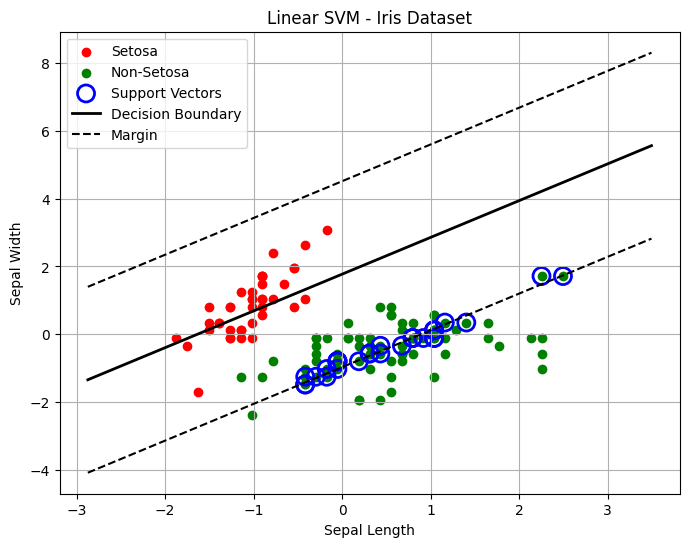


Margin: 3.717418904198337

Margin Explanation:
The margin is the distance between the two margin boundaries.
A larger margin generally gives better separation between classes.
The support vectors are the points closest to the decision boundary.
They determine the position of the optimal separating hyperplane.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

iris = load_iris()

X = iris.data[:, :2]
y = np.where(iris.target == 0, -1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

w = np.zeros(2)
b = 0

learning_rate = 0.001
C = 1
epochs = 10000

for epoch in range(epochs):
    for i in range(len(X_train)):
        decision = np.dot(w, X_train[i]) + b

        if y_train[i] * decision >= 1:
            w = w - learning_rate * w
        else:
            w = w - learning_rate * (w - C * y_train[i] * X_train[i])
            b = b + learning_rate * C * y_train[i]

def decision_function(x):
    return np.dot(x, w) + b

def predict(x):
    return np.where(decision_function(x) >= 0, 1, -1)

y_pred = predict(X_test)

print("Weight vector:", w)
print("Bias:", b)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Setosa", "Non-Setosa"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

decision_values = decision_function(X_train)

support_vector_indices = np.where(
    np.abs(np.abs(decision_values) - 1) <= 0.1
)[0]

support_vectors = X_train[support_vector_indices]

print("\nNumber of Support Vectors:", len(support_vectors))
print("Support Vectors:")
print(support_vectors)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_train[y_train == -1, 0],
    X_train[y_train == -1, 1],
    color="red",
    label="Setosa"
)

plt.scatter(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    color="green",
    label="Non-Setosa"
)

if len(support_vectors) > 0:
    plt.scatter(
        support_vectors[:, 0],
        support_vectors[:, 1],
        s=150,
        facecolors="none",
        edgecolors="blue",
        linewidths=2,
        label="Support Vectors"
    )

x_values = np.linspace(
    X_train[:, 0].min() - 1,
    X_train[:, 0].max() + 1,
    100
)

y_boundary = -(w[0] * x_values + b) / w[1]
y_margin_positive = -(w[0] * x_values + b - 1) / w[1]
y_margin_negative = -(w[0] * x_values + b + 1) / w[1]

plt.plot(
    x_values,
    y_boundary,
    "k-",
    linewidth=2,
    label="Decision Boundary"
)

plt.plot(
    x_values,
    y_margin_positive,
    "k--",
    label="Margin"
)

plt.plot(
    x_values,
    y_margin_negative,
    "k--"
)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Linear SVM - Iris Dataset")
plt.legend()
plt.grid()
plt.show()

margin = 2 / np.linalg.norm(w)

print("\nMargin:", margin)

print("\nMargin Explanation:")
print("The margin is the distance between the two margin boundaries.")
print("A larger margin generally gives better separation between classes.")
print("The support vectors are the points closest to the decision boundary.")
print("They determine the position of the optimal separating hyperplane.")


# 3. Comparison of SVM Classifiers with Different Kernels on Fashion MNIST

## Problem Statement

Implement and compare the performance of SVM classifiers using **linear, polynomial, and RBF kernels** on the Fashion MNIST dataset.

## Tasks

1. Load and preprocess the Fashion MNIST dataset.
2. Prepare the dataset for SVM classification.
3. Implement SVM classifiers using:
   - Linear kernel
   - Polynomial kernel
   - RBF kernel
4. Train the SVM classifiers on the dataset.
5. Evaluate the classification performance of each kernel.
6. Compare the classifiers using suitable performance metrics such as:
   - Accuracy
   - Precision
   - Recall
   - F1-score
7. Compare the training and prediction performance of the different kernels.
8. Analyze the advantages and disadvantages of each kernel type.



 Linear Kernel
----------------
Accuracy : 0.801
Precision: 0.8015
Recall   : 0.801
F1 Score : 0.8007
Training Time: 8.21 seconds
Prediction Time: 3.05 seconds

 Polynomial Kernel
----------------
Accuracy : 0.826
Precision: 0.8378
Recall   : 0.826
F1 Score : 0.8299
Training Time: 10.52 seconds
Prediction Time: 4.68 seconds

 RBF Kernel
----------------
Accuracy : 0.8455
Precision: 0.8443
Recall   : 0.8455
F1 Score : 0.8436
Training Time: 8.34 seconds
Prediction Time: 8.5 seconds

Comparison
---------------------------------------------------------------
Kernel       Accuracy   Precision   Recall   F1 Score   Train Time
---------------------------------------------------------------
Linear       0.8010     0.8015      0.8010    0.8007     8.21s
Polynomial   0.8260     0.8378      0.8260    0.8299     10.52s
RBF          0.8455     0.8443      0.8455    0.8436     8.34s


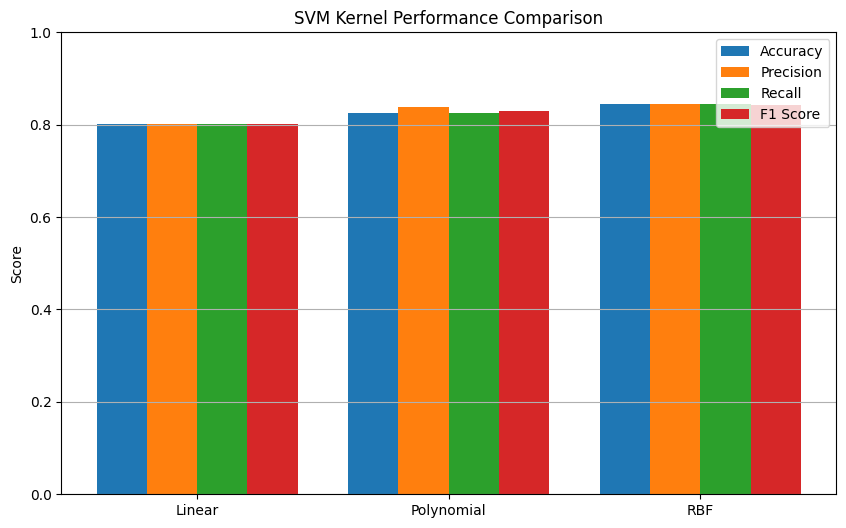


Best Kernel based on Accuracy: RBF


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X, y = fetch_openml(
    "Fashion-MNIST",
    version=1,
    return_X_y=True,
    as_frame=False
)

X = X.astype("float32") / 255.0
y = y.astype(int)

X, _, y, _ = train_test_split(
    X, y,
    train_size=10000,
    random_state=42,
    stratify=y
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

models = {
    "Linear": SVC(kernel="linear"),
    "Polynomial": SVC(kernel="poly", degree=3),
    "RBF": SVC(kernel="rbf")
}

results = {}

for name, model in models.items():

    start = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_test)
    prediction_time = time.time() - start

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    results[name] = [
        accuracy,
        precision,
        recall,
        f1,
        training_time,
        prediction_time
    ]

    print("\n", name, "Kernel")
    print("----------------")
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("Training Time:", round(training_time, 2), "seconds")
    print("Prediction Time:", round(prediction_time, 2), "seconds")

print("\nComparison")
print("---------------------------------------------------------------")
print("Kernel       Accuracy   Precision   Recall   F1 Score   Train Time")
print("---------------------------------------------------------------")

for name, values in results.items():
    print(
        f"{name:<12}",
        f"{values[0]:<10.4f}",
        f"{values[1]:<11.4f}",
        f"{values[2]:<9.4f}",
        f"{values[3]:<10.4f}",
        f"{values[4]:.2f}s"
    )

names = list(results.keys())
accuracy = [results[name][0] for name in names]
precision = [results[name][1] for name in names]
recall = [results[name][2] for name in names]
f1 = [results[name][3] for name in names]

x = np.arange(len(names))
width = 0.2

plt.figure(figsize=(10, 6))

plt.bar(x - 1.5 * width, accuracy, width, label="Accuracy")
plt.bar(x - 0.5 * width, precision, width, label="Precision")
plt.bar(x + 0.5 * width, recall, width, label="Recall")
plt.bar(x + 1.5 * width, f1, width, label="F1 Score")

plt.xticks(x, names)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("SVM Kernel Performance Comparison")
plt.legend()
plt.grid(axis="y")
plt.show()
best_kernel = names[np.argmax(accuracy)]

print("\nBest Kernel based on Accuracy:", best_kernel)
